Unit conversion: 1 u/e = 1.036427e-08 kg/C

Fitting Results (with unit conversion)

Input data:
  m/q = 2.606748781, 2.606767671 u/e
  T   = 1250.410644, 1250.414685 ns
  Conversion: 1 u/e = 1.036427e-08 kg/C = 931.494 MeV/e

Fit parameters:
  p0 (L/c) = 9.250226e-07 ± 5.740858e-13 s
  p1 = (c·(u/e)/Bρ)² = 1.217431e-01 ± 3.342231e-07

Physical quantities:
  Circumference L = 0.2773 ± 0.0000 km
         = 277.31 ± 0.00 m
  Magnetic rigidity Bρ = 8.9051 ± 0.0000 T·m
  Magnetic rigidity Bρ = 89050.68 ± 0.12 kG·m

Detailed calculation results (with scientific notation)

Circumference L:
  L = p0 × c
    = (9.250226e-07 s) × (2.997925e+08 m/s)
    = 2.773148e+02 m
  Error: σ_L = σ_p0 × c = (5.740858e-13 s) × (2.997925e+08 m/s) = 1.721066e-04 m
  Relative error: σ_L/L = 6.206182e-07 (6.206182e-05%)

  → L = (2.773148e+02 ± 1.721066e-04) m
  → L = 277.3147955166 ± 0.0001721066 m

Magnetic rigidity Bρ:
  Bρ = c × (u/e) / √p1
  where:
    c = 2.997925e+08 m/s
    u/e = 1.036427e-08 kg/C
    c ×

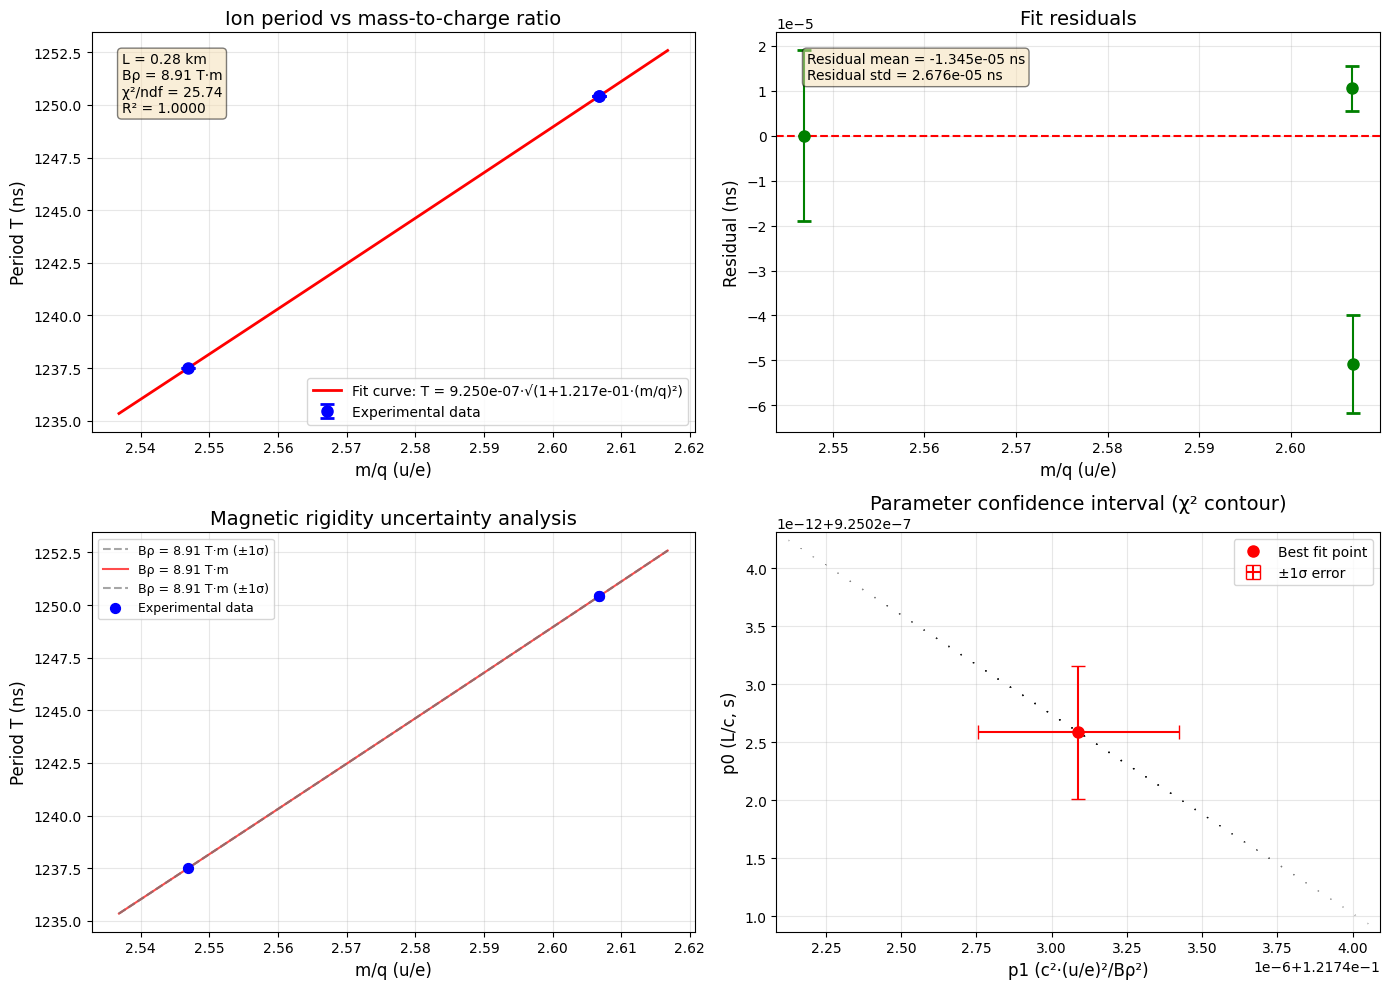


Plots saved as ion_period_fit_with_units.png and ion_period_fit_with_units.pdf

Unit conversion explanation
Physical constants:
  c = 2.997925e+08 m/s
  e = 1.602177e-19 C
  u = 1.660539e-27 kg = 931.494 MeV/c²

Conversion relations:
  1 u/e = 1.036427e-08 kg/C
  1 u/e × c = 3.107130e+00 (kg·m/s)/C = T·m·s?

(mc/q) term in the formula:
  (m/q) in u/e → (m/q) in kg/C = (m/q)_u/e × 1.036e-08
  (mc/q) = (m/q)_kg/C × c = (m/q)_u/e × 3.107e+00 (T·m·s?)

Magnetic rigidity Bρ unit: T·m
  Bρ = 8.9051 T·m
  (mc/q)/Bρ dimensionless = 0.348917 (from fit)

FINAL SUMMARY

Circumference L = 277.31479552 ± 0.00017211 m
                = 0.27731480 ± 0.00000017 km

Magnetic rigidity Bρ = 8.90506819 ± 0.00001222 T·m
                     = 89050.68188225 ± 0.12223606 kG·m

Relative uncertainties:
  σ_L/L = 6.21e-07 (6.2062e-05%)
  σ_Bρ/Bρ = 1.37e-06 (1.3727e-04%)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats

# Physical constants
c = 2.99792458e8          # Speed of light (m/s)
e = 1.602176634e-19       # Elementary charge (C)
u_kg = 1.66053906660e-27  # Atomic mass unit (kg)
u_MeV = 931.494061        # Atomic mass unit (MeV/c²)

# Unit conversion
u_per_e = u_kg / e        # 1 u/e = ? kg/C
print(f"Unit conversion: 1 u/e = {u_per_e:.6e} kg/C")

# Data points (m/q unit: u/e)
mq_u_per_e = np.array([2.606748781,2.606767671,2.546835098])  # u/e
T_ns = np.array([1250.410644,1250.414685,1237.481997])        # T (ns)
T_err_ns = np.array([0.000005,0.000011,0.000019])                    # Error (ns)

# Convert to SI units (kg/C)
mq_kg_per_C = mq_u_per_e * u_per_e  # kg/C

# Convert to convenient form: (mc²)/q unit: MeV/e
mq_MeV_per_e = mq_u_per_e * u_MeV   # (MeV/c²)/e, but actually mc²/q in units MeV/e

def period_function(mq, L, Brho):
    """
    Period function
    mq: mass-to-charge ratio, unit kg/C
    L: circumference, unit m
    Brho: magnetic rigidity, unit T·m
    Returns: period T, unit s
    """
    mc_over_q = mq * c  # (m/q) * c = (mc)/q, unit kg·m/s / C = (kg·m/s)/C
    return (L / c) * np.sqrt(1 + (mc_over_q / Brho)**2)

def period_function_params(mq, p0, p1):
    """
    Parameterized form: T = p0 * sqrt(1 + p1 * (mq_u_per_e)^2)
    p0 = L/c (unit s)
    p1 = (c * u_per_e / Bρ)^2 or (c * (u/e) / Bρ)^2
    """
    return p0 * np.sqrt(1 + p1 * mq**2)

# Use parameterized form for fitting
mq_input = mq_u_per_e  # Use u/e units for fitting, parameters more intuitive

# Initial parameter estimates
est_p1 = 0.1  # Initial guess
est_p0 = T_ns[0] * 1e-9 / np.sqrt(1 + est_p1 * mq_input[0]**2)

# Perform fitting
sigma = T_err_ns * 1e-9  # Convert to seconds
popt, pcov = curve_fit(period_function_params, mq_input, T_ns * 1e-9, 
                       p0=[est_p0, est_p1], sigma=sigma, absolute_sigma=True)

# Extract fit parameters
p0, p1 = popt
p0_err, p1_err = np.sqrt(np.diag(pcov))

# Calculate physical quantities
L = p0 * c                    # Circumference (m)
L_err = p0_err * c

Brho = c * u_per_e / np.sqrt(p1)  # Magnetic rigidity (T·m)
# Error propagation
Brho_err = Brho * 0.5 * p1_err / p1

# Calculate fit values
T_fit_s = period_function_params(mq_input, p0, p1)
T_fit_ns = T_fit_s * 1e9

# Calculate residuals
residuals_ns = T_ns - T_fit_ns

# Calculate goodness of fit
chi2 = np.sum((residuals_ns * 1e-9 / sigma)**2)
dof = len(mq_input) - len(popt)
chi2_red = chi2 / dof

# Output results
print("\n" + "="*60)
print("Fitting Results (with unit conversion)")
print("="*60)
print(f"\nInput data:")
print(f"  m/q = {mq_u_per_e[0]:.9f}, {mq_u_per_e[1]:.9f} u/e")
print(f"  T   = {T_ns[0]:.6f}, {T_ns[1]:.6f} ns")
print(f"  Conversion: 1 u/e = {u_per_e:.6e} kg/C = {u_MeV:.3f} MeV/e")
print(f"\nFit parameters:")
print(f"  p0 (L/c) = {p0:.6e} ± {p0_err:.6e} s")
print(f"  p1 = (c·(u/e)/Bρ)² = {p1:.6e} ± {p1_err:.6e}")
print(f"\nPhysical quantities:")
print(f"  Circumference L = {L/1000:.4f} ± {L_err/1000:.4f} km")
print(f"         = {L:.2f} ± {L_err:.2f} m")
print(f"  Magnetic rigidity Bρ = {Brho:.4f} ± {Brho_err:.4f} T·m")
print(f"  Magnetic rigidity Bρ = {Brho*1e4:.2f} ± {Brho_err*1e4:.2f} kG·m")

# Add detailed output with scientific notation
print("\n" + "="*60)
print("Detailed calculation results (with scientific notation)")
print("="*60)
print(f"\nCircumference L:")
print(f"  L = p0 × c")
print(f"    = ({p0:.6e} s) × ({c:.6e} m/s)")
print(f"    = {L:.6e} m")
print(f"  Error: σ_L = σ_p0 × c = ({p0_err:.6e} s) × ({c:.6e} m/s) = {L_err:.6e} m")
print(f"  Relative error: σ_L/L = {L_err/L:.6e} ({L_err/L*100:.6e}%)")
print(f"\n  → L = ({L:.6e} ± {L_err:.6e}) m")
print(f"  → L = {L:.10f} ± {L_err:.10f} m")

print(f"\nMagnetic rigidity Bρ:")
print(f"  Bρ = c × (u/e) / √p1")
print(f"  where:")
print(f"    c = {c:.6e} m/s")
print(f"    u/e = {u_per_e:.6e} kg/C")
print(f"    c × (u/e) = {c*u_per_e:.6e} T·m")
print(f"    √p1 = √({p1:.6e}) = {np.sqrt(p1):.6e}")
print(f"  Bρ = {c*u_per_e:.6e} / {np.sqrt(p1):.6e} = {Brho:.6e} T·m")
print(f"  Error propagation:")
print(f"    σ_Bρ/Bρ = (1/2) × (σ_p1/p1)")
print(f"    σ_p1/p1 = {p1_err:.6e} / {p1:.6e} = {p1_err/p1:.6e}")
print(f"    σ_Bρ/Bρ = 0.5 × {p1_err/p1:.6e} = {0.5*p1_err/p1:.6e}")
print(f"    σ_Bρ = {Brho:.6e} × {0.5*p1_err/p1:.6e} = {Brho_err:.6e} T·m")
print(f"  Relative error: σ_Bρ/Bρ = {Brho_err/Brho:.6e} ({Brho_err/Brho*100:.6e}%)")
print(f"\n  → Bρ = ({Brho:.6e} ± {Brho_err:.6e}) T·m")
print(f"  → Bρ = {Brho:.10f} ± {Brho_err:.10f} T·m")
print(f"  → Bρ = {Brho*1e4:.6e} ± {Brho_err*1e4:.6e} kG·m")

# Verify consistency with fit parameters
print("\n" + "="*60)
print("Consistency check")
print("="*60)
p1_reconstructed = (c * u_per_e / Brho)**2
print(f"p1 from Bρ: (c·(u/e)/Bρ)² = {p1_reconstructed:.6e}")
print(f"p1 from fit: {p1:.6e}")
print(f"Difference: {abs(p1_reconstructed - p1):.6e}")

print(f"\nGoodness of fit:")
print(f"  χ² = {chi2:.4f}")
print(f"  Degrees of freedom = {dof}")
print(f"  Reduced χ² = {chi2_red:.4f}")
print(f"  R² = {1 - np.sum(residuals_ns**2)/np.sum((T_ns - np.mean(T_ns))**2):.6f}")

print(f"\nComparison of fit and measured values:")
print(f"{'m/q (u/e)':<15} {'T_meas (ns)':<15} {'T_fit (ns)':<15} {'Residual (ns)':<15} {'Rel. error (%)':<15}")
print("-"*75)
for i in range(len(mq_input)):
    rel_err = abs(residuals_ns[i] / T_ns[i]) * 100
    print(f"{mq_input[i]:<15.9f} {T_ns[i]:<15.6f} {T_fit_ns[i]:<15.6f} {residuals_ns[i]:<15.6f} {rel_err:<15.4f}")

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Data points and fit curve
ax1 = axes[0, 0]
mq_plot = np.linspace(min(mq_input)-0.01, max(mq_input)+0.01, 100)
T_plot_ns = period_function_params(mq_plot, p0, p1) * 1e9

ax1.errorbar(mq_input, T_ns, yerr=T_err_ns, fmt='o', color='blue', 
             capsize=5, capthick=2, markersize=8, label='Experimental data')
ax1.plot(mq_plot, T_plot_ns, 'r-', linewidth=2, 
         label=f'Fit curve: T = {p0:.3e}·√(1+{p1:.3e}·(m/q)²)')
ax1.set_xlabel('m/q (u/e)', fontsize=12)
ax1.set_ylabel('Period T (ns)', fontsize=12)
ax1.set_title('Ion period vs mass-to-charge ratio', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

textstr = f'L = {L/1000:.2f} km\nBρ = {Brho:.2f} T·m\nχ²/ndf = {chi2_red:.2f}\nR² = {1 - np.sum(residuals_ns**2)/np.sum((T_ns - np.mean(T_ns))**2):.4f}'
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Residual distribution
ax2 = axes[0, 1]
ax2.errorbar(mq_input, residuals_ns, yerr=T_err_ns, fmt='o', color='green', 
             capsize=5, capthick=2, markersize=8)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('m/q (u/e)', fontsize=12)
ax2.set_ylabel('Residual (ns)', fontsize=12)
ax2.set_title('Fit residuals', fontsize=14)
ax2.grid(True, alpha=0.3)

res_mean = np.mean(residuals_ns)
res_std = np.std(residuals_ns)
ax2.text(0.05, 0.95, f'Residual mean = {res_mean:.3e} ns\nResidual std = {res_std:.3e} ns', 
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Physical parameter correlation
ax3 = axes[1, 0]
# Calculate period curves for different Bρ values
Brho_values = [Brho - Brho_err, Brho, Brho + Brho_err]
colors = ['gray', 'red', 'gray']
linestyles = ['--', '-', '--']

for Bv, col, ls in zip(Brho_values, colors, linestyles):
    T_curve = (L / c) * np.sqrt(1 + (mq_plot * u_per_e * c / Bv)**2) * 1e9
    label = f'Bρ = {Bv:.2f} T·m' if Bv == Brho else f'Bρ = {Bv:.2f} T·m (±1σ)'
    ax3.plot(mq_plot, T_curve, color=col, linestyle=ls, linewidth=1.5, alpha=0.7, label=label)

ax3.scatter(mq_input, T_ns, color='blue', s=50, zorder=5, label='Experimental data')
ax3.set_xlabel('m/q (u/e)', fontsize=12)
ax3.set_ylabel('Period T (ns)', fontsize=12)
ax3.set_title('Magnetic rigidity uncertainty analysis', fontsize=14)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Parameter confidence interval
ax4 = axes[1, 1]
# Calculate χ² surface
p0_grid = np.linspace(p0 - 3*p0_err, p0 + 3*p0_err, 50)
p1_grid = np.linspace(p1 - 3*p1_err, p1 + 3*p1_err, 50)
chi2_grid = np.zeros((len(p0_grid), len(p1_grid)))

for i, p0_val in enumerate(p0_grid):
    for j, p1_val in enumerate(p1_grid):
        T_fit_test = period_function_params(mq_input, p0_val, p1_val)
        chi2_grid[i, j] = np.sum(((T_ns*1e-9 - T_fit_test) / sigma)**2)

# Plot χ² contour
contour = ax4.contour(p1_grid, p0_grid, chi2_grid, levels=[chi2+1, chi2+2.3, chi2+4, chi2+9], 
                      colors='black', linewidths=1)
ax4.clabel(contour, inline=True, fontsize=8, fmt='Δχ²=%.1f')
ax4.plot(p1, p0, 'ro', markersize=8, label='Best fit point')
ax4.errorbar(p1, p0, xerr=p1_err, yerr=p0_err, fmt='none', color='red', capsize=5, label='±1σ error')
ax4.set_xlabel('p1 (c²·(u/e)²/Bρ²)', fontsize=12)
ax4.set_ylabel('p0 (L/c, s)', fontsize=12)
ax4.set_title('Parameter confidence interval (χ² contour)', fontsize=14)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ion_period_fit_with_units.png', dpi=300, bbox_inches='tight')
plt.savefig('ion_period_fit_with_units.pdf', bbox_inches='tight')
plt.show()

print("\nPlots saved as ion_period_fit_with_units.png and ion_period_fit_with_units.pdf")

# Output unit conversion information
print("\n" + "="*60)
print("Unit conversion explanation")
print("="*60)
print(f"Physical constants:")
print(f"  c = {c:.6e} m/s")
print(f"  e = {e:.6e} C")
print(f"  u = {u_kg:.6e} kg = {u_MeV:.3f} MeV/c²")
print(f"\nConversion relations:")
print(f"  1 u/e = {u_per_e:.6e} kg/C")
print(f"  1 u/e × c = {u_per_e*c:.6e} (kg·m/s)/C = T·m·s?")
print(f"\n(mc/q) term in the formula:")
print(f"  (m/q) in u/e → (m/q) in kg/C = (m/q)_u/e × {u_per_e:.3e}")
print(f"  (mc/q) = (m/q)_kg/C × c = (m/q)_u/e × {u_per_e*c:.3e} (T·m·s?)")
print(f"\nMagnetic rigidity Bρ unit: T·m")
print(f"  Bρ = {Brho:.4f} T·m")
print(f"  (mc/q)/Bρ dimensionless = {np.sqrt(p1):.6f} (from fit)")

# Final summary
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"\nCircumference L = {L:.8f} ± {L_err:.8f} m")
print(f"                = {L/1000:.8f} ± {L_err/1000:.8f} km")
print(f"\nMagnetic rigidity Bρ = {Brho:.8f} ± {Brho_err:.8f} T·m")
print(f"                     = {Brho*1e4:.8f} ± {Brho_err*1e4:.8f} kG·m")
print(f"\nRelative uncertainties:")
print(f"  σ_L/L = {L_err/L:.2e} ({L_err/L*100:.4e}%)")
print(f"  σ_Bρ/Bρ = {Brho_err/Brho:.2e} ({Brho_err/Brho*100:.4e}%)")